In [1]:
import sys
sys.path.append('/home/artemybombastic/MyGit/KD_Summer_Work/Segmentation')
from Loop import Train_model
from Model import Unet
from torchvision.transforms.functional import adjust_sharpness,adjust_contrast
from Dataset import Eval_Boot_Segmentation_Dataset
import yaml
from PIL import Image
import cv2
from torch.nn import functional as F
from Batching import img2batch,batch2img,img4batch,batch4img
from torch.optim import AdamW
from torch.nn import BCELoss
import torch
from torch import nn
import torch.utils.data as data_utils
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader
import numpy as np

In [2]:
def cut_boot_from_photo(img,mask):
    sig=nn.Sigmoid()
    real_mask = (sig(mask)>(sig(mask).max()+sig(mask).min())/2) 
    return real_mask

In [3]:
option_path=fr'/home/artemybombastic/MyGit/KD_Summer_Work/config.yml'
device='cuda' if torch.cuda.is_available() else 'cpu'
device='cpu'
print(device)
with open(option_path,'r') as file_option:
    option=yaml.safe_load(file_option)



cpu


In [91]:
def bb_finder(img):
    rows=torch.any(img>0,dim=1)
    columns=torch.any(img>0,dim=0)

    r_min=torch.where(rows)[0][0]
    r_max=torch.where(rows)[0][-1]

    c_min=torch.where(columns)[0][0]
    c_max=torch.where(columns)[0][-1]

    print(r_min,r_max+1,c_min,c_max+1)
    return img[:,r_min:r_max+1,c_min:c_max+1]

In [5]:
eval_dataset=Eval_Boot_Segmentation_Dataset('/home/artemybombastic/MyGit/KD_Data/TransformData/low_boots',option['Segmentation']['label_path'],)
eval_dataloader=DataLoader(dataset=eval_dataset,batch_size=1,drop_last=False,shuffle=False)

In [6]:
model=Unet(3,64).to(device)

In [7]:
try:
    weights_dict=torch.load(f'/home/artemybombastic/MyGit/KD_Data/SegmData/unet_model_{device}.pth',weights_only=True)
    model.load_state_dict(weights_dict)
except:
    print('Весов нет, инициализируем новые')

In [8]:
bt=0
for batch in eval_dataloader:
    bt=batch
    break

In [9]:
pred=model(bt['img'])

In [88]:
torch.where(torch.any(a>0,dim=1))

(tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0

In [89]:
a.shape

torch.Size([1, 1024, 512])

In [70]:
a=cut_boot_from_photo(bt['img'][0],pred[0])

In [92]:
b=bb_finder(a[0])

tensor(564) tensor(788) tensor(81) tensor(458)


IndexError: too many indices for tensor of dimension 2

In [75]:
b

tensor([], size=(1, 1, 0), dtype=torch.bool)

In [64]:
a[0].shape

torch.Size([1024, 512])

In [68]:
a[0][50]

tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, 

In [13]:
b.shape

torch.Size([1, 1, 0])

/tmp/ipykernel_28839/1920336088.py:1: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(b.permute(1,2,0).detach())


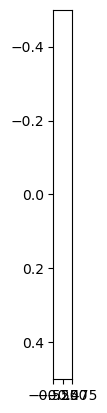

In [14]:
plt.imshow(b.permute(1,2,0).detach())

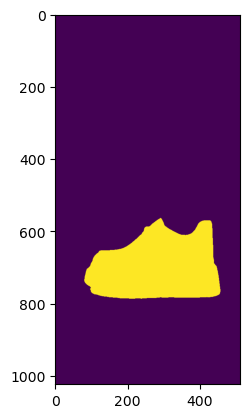

In [33]:
plt.imshow(a.permute(1,2,0).detach())

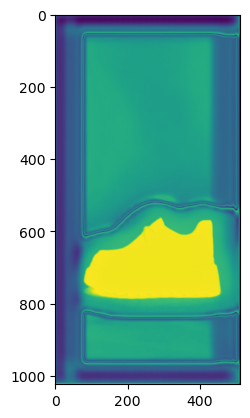

In [16]:
plt.imshow(pred[0].permute(1,2,0).detach())

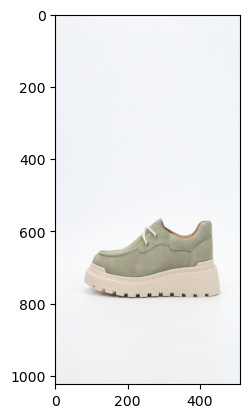

In [17]:
plt.imshow(eval_dataset[0]['img'].permute(1,2,0).detach())